# **End-to-End Customer Intelligence System**

# **Import Libraries**

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    silhouette_score,
    classification_report,
    confusion_matrix
)

sns.set_style("whitegrid")

# **Load the dataset**

In [105]:
import kagglehub



# Download latest version

path = kagglehub.dataset_download("rohan0301/unsupervised-learning-on-country-data")



print("Path to dataset files:", path)

Using Colab cache for faster access to the 'unsupervised-learning-on-country-data' dataset.
Path to dataset files: /kaggle/input/unsupervised-learning-on-country-data


# **Data inspection**

In [106]:
import os

print(os.listdir(path))

['Country-data.csv', 'data-dictionary.csv']


In [107]:
file_path = os.path.join(path, "Country-data.csv")

df = pd.read_csv(file_path)

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [108]:
dictionary_path = os.path.join(path, "data-dictionary.csv")

data_dict = pd.read_csv(dictionary_path)

data_dict

,Column Name,Description
0,country,Name of the country
1,child_mort,Death of children under 5 years of age per 100...
2,exports,Exports of goods and services per capita. Give...
3,health,Total health spending per capita. Given as %ag...
4,imports,Imports of goods and services per capita. Give...
5,Income,Net income per person
6,Inflation,The measurement of the annual growth rate of t...
7,life_expec,The average number of years a new born child w...
8,total_fer,The number of children that would be born to e...
9,gdpp,The GDP per capita. Calculated as the Total GD...


In [109]:
df.shape

(167, 10)

In [110]:
df.columns.tolist()

['country',
 'child_mort',
 'exports',
 'health',
 'imports',
 'income',
 'inflation',
 'life_expec',
 'total_fer',
 'gdpp']

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [112]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


# **Data Cleaning**
To ensure data quality and remove inconsistencies that could negatively affect model performance.

In [113]:
# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert columns to numeric
for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill missing values
numeric_cols = df.select_dtypes(include='number').columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print(df.isnull().sum())

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


# **Exploratory Data Analysis**

**Corelaton Heatmap**

To identify relationships between variables and understand which indicators are strongly associated with development status.

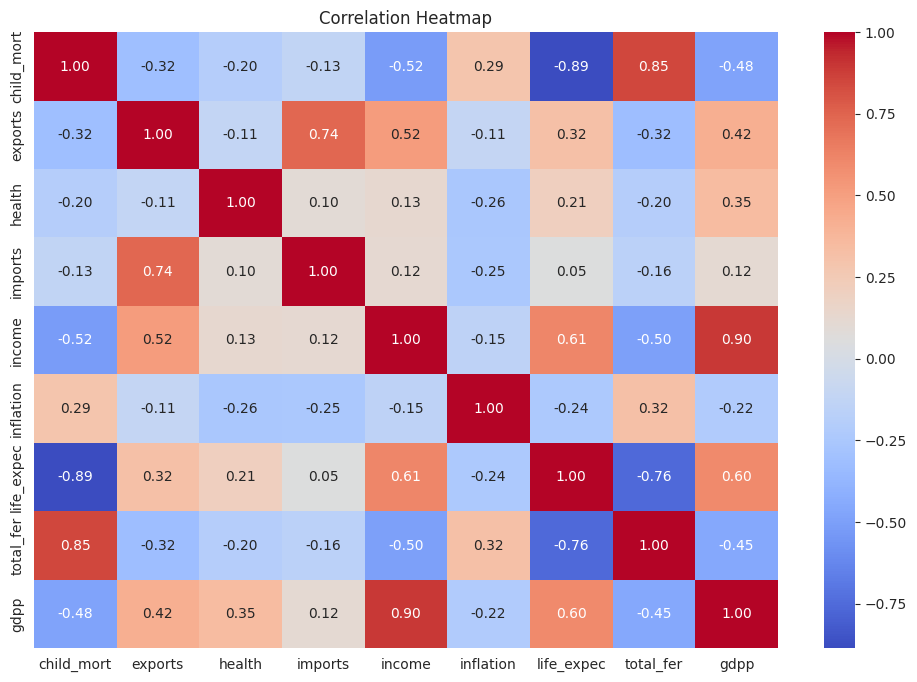

In [114]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**Outlier Analysis**

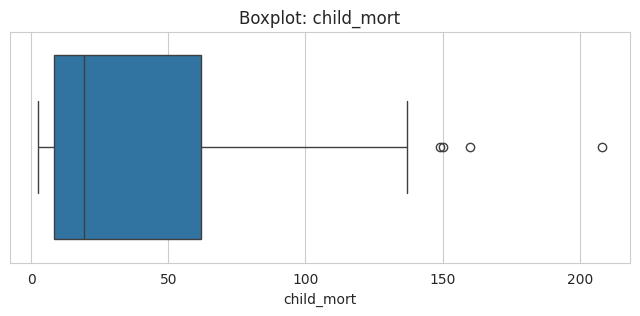

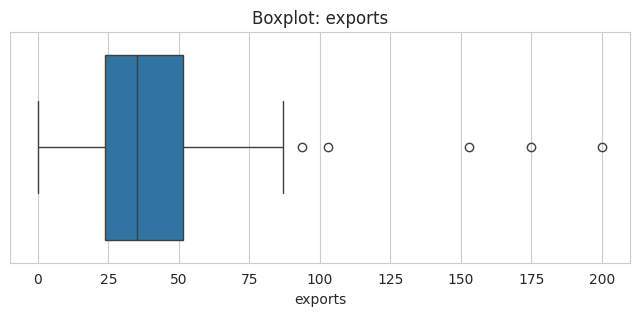

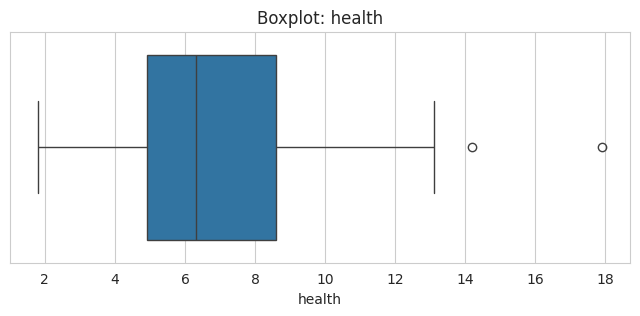

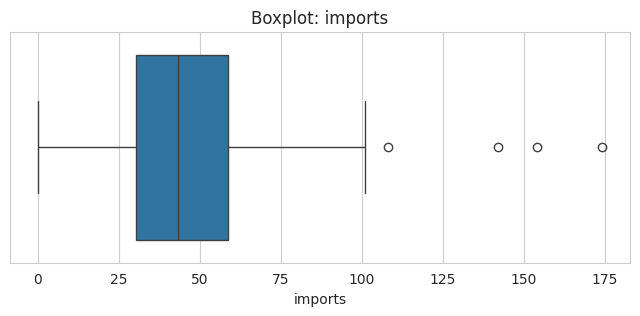

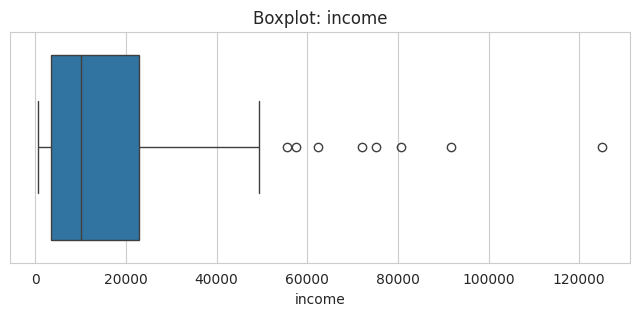

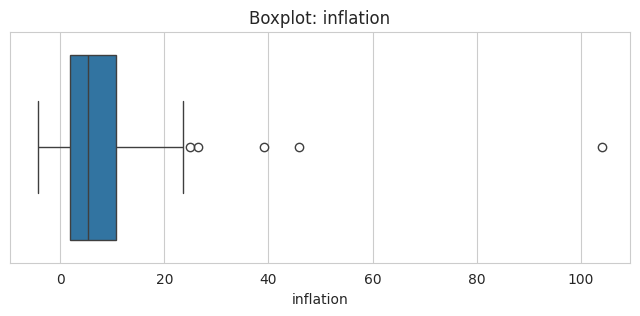

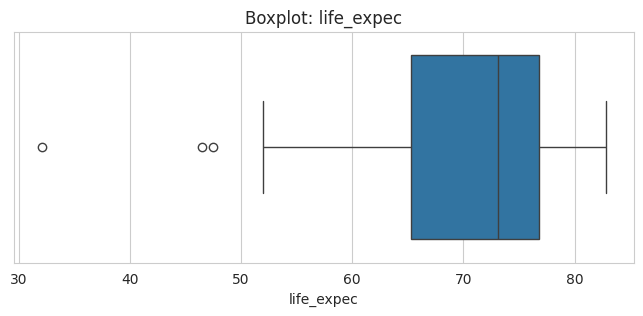

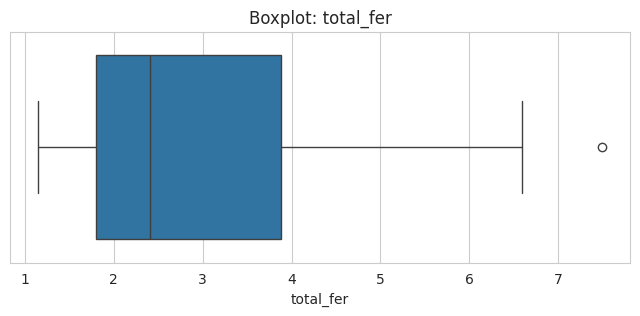

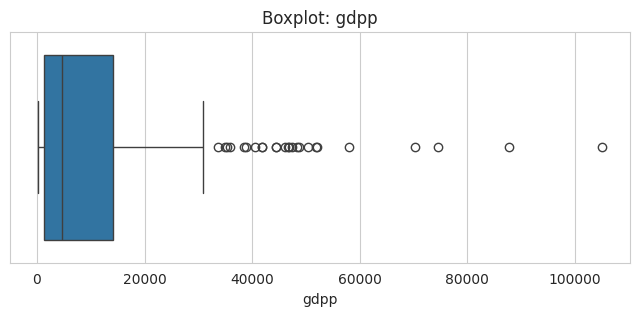

In [115]:
for col in numeric_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

**Insight**

The presence of outliers highlights the substantial disparity in economic development and quality of life across countries. These extreme observations are crucial for identifying nations that require policy intervention, development assistance, or special economic consideration.

# **Create Target Variable**

To transform the continuous GDP per capita variable into categorical development classes for supervised classification.

In [116]:
df["development_level"] = pd.qcut(df["gdpp"],q=3,labels=["Low","Medium","High"])

df["development_level"].value_counts()

,count
development_level,
Low,56
High,56
Medium,55


# **Prepare Features**

In [117]:
X = df[numeric_cols]

y = df["development_level"]

encoder = LabelEncoder()

y = encoder.fit_transform(y)

# **Train-Test Split**

To evaluate model performance on unseen data and ensure generalization.


In [118]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **Feature scaling**

In [119]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

**Logistic Regression**

In [120]:
lr = LogisticRegression(max_iter=5000)

lr.fit(X_train_scaled,y_train)

pred_lr = lr.predict(X_test_scaled)

print("Accuracy:",accuracy_score(y_test,pred_lr))

Accuracy: 0.8529411764705882


**Random Forest**

In [121]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

print("RF Accuracy:",accuracy_score(y_test,pred_rf))

RF Accuracy: 1.0


**XGBoost**

In [122]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train,y_train)

pred_xgb = xgb.predict(X_test)

print("XGB Accuracy:",accuracy_score(y_test,pred_xgb))

XGB Accuracy: 1.0


**Compare Models**

To identify the most effective classification algorithm.

In [123]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy":[
        accuracy_score(y_test,pred_lr),
        accuracy_score(y_test,pred_rf),
        accuracy_score(y_test,pred_xgb)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.852941
1        Random Forest  1.000000
2              XGBoost  1.000000


Random Forest and XGBoost clearly outperformed the baseline model.

# **Feature Selection**

Clustering requires only numerical features that describe country characteristics.

-Country names and target labels were removed.

-Only socio-economic indicators were retained for segmentation.

In [124]:
features = df.drop(columns=["country", "development_level"])

scaler = StandardScaler()

X_scaled = scaler.fit_transform(features)

In [125]:
X_scaled.shape

(167, 9)

# **Elbow Method**

To determine the optimal number of clusters for K-Means.


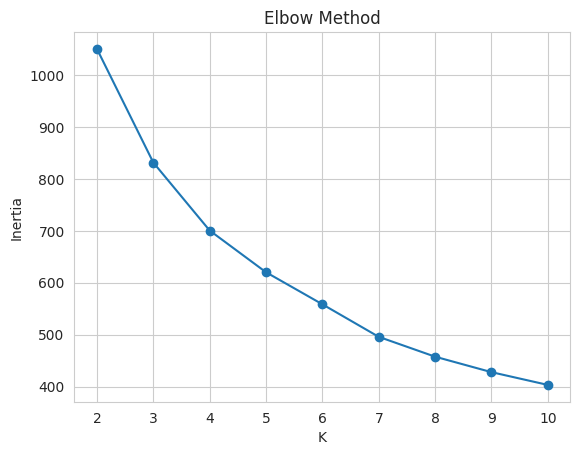

In [126]:
inertia = []

for k in range(2,11):

    model = KMeans(n_clusters=k,random_state=42,n_init=10)

    model.fit(X_scaled)

    inertia.append(model.inertia_)

plt.plot(range(2,11),inertia,marker="o")

plt.xlabel("K")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

# **Train K-Means**
used k=3 as given in instructions

In [127]:
best_k = 3

kmeans = KMeans(n_clusters=best_k,random_state=42,n_init=10)

df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

To group countries with similar socio-economic characteristics.

# **Silhouette Score**

To evaluate the quality of clustering.

In [128]:
score = silhouette_score(X_scaled,df["kmeans_cluster"])

print( "Silhouette Score at k=3 :",score)

Silhouette Score at k=3 : 0.28329575683463126


In [129]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    scores.append(score)

    print(
        f"K={k} --> Silhouette Score={score:.4f}"
    )

K=2 --> Silhouette Score=0.2874
K=3 --> Silhouette Score=0.2833
K=4 --> Silhouette Score=0.2960
K=5 --> Silhouette Score=0.2993
K=6 --> Silhouette Score=0.2287
K=7 --> Silhouette Score=0.2477
K=8 --> Silhouette Score=0.2388
K=9 --> Silhouette Score=0.2073
K=10 --> Silhouette Score=0.2022


In [130]:
best_k = range(2,11)[np.argmax(scores)]

best_score = max(scores)

print("Best K:", best_k)

print("Best Score:", best_score)

Best K: 5
Best Score: 0.2992594995920442


**Insight**

The K-Means model with k=3 achieved a Silhouette Score of approximately 0.28, indicating moderate cluster separation while best score is at k=5 which is approximately 0.30 .While some overlap exists among country groups, the clustering successfully identifies meaningful patterns in socio-economic development and provides useful segmentation insights.

# **DBSCAN**
To identify density-based clusters and detect outliers.

In [131]:
dbscan = DBSCAN(eps=1.5,min_samples=5)

df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

print( df["dbscan_cluster"].value_counts().sort_index())

dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64



**Insight**

-Most countries belonged to a single dense cluster.

-Several countries were identified as outliers.

-These outliers represent unique socio-economic profiles.

# **PCA Visualization**

To reduce dimensionality and visualize cluster separation.

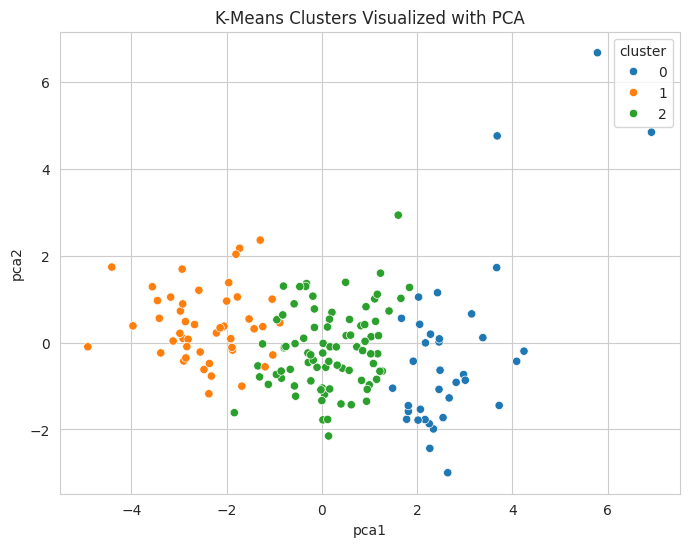

In [132]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

viz = pd.DataFrame({
    'pca1': X_pca[:, 0],
    'pca2': X_pca[:, 1],
    'cluster': df['kmeans_cluster']
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=viz, x='pca1', y='pca2', hue='cluster', palette='tab10')
plt.title('K-Means Clusters Visualized with PCA')
plt.show()


**Insight**

-PCA reduced nine features into two principal components.

-Major clusters became visually distinguishable.

-Visualization confirmed the effectiveness of K-Means segmentation.

# **Cluster Profiling**

To understand the characteristics of each cluster.

In [133]:
profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


# **Country Lists per Cluster**

To identify which countries belong to each segment.

In [134]:
for cluster in sorted(df["kmeans_cluster"].unique()):

    print("\nCluster",cluster)

    print(df[df["kmeans_cluster"]==cluster]["country"].tolist())


Cluster 0
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland', 'France', 'Germany', 'Greece', 'Iceland', 'Ireland', 'Israel', 'Italy', 'Japan', 'Kuwait', 'Luxembourg', 'Malta', 'Netherlands', 'New Zealand', 'Norway', 'Portugal', 'Qatar', 'Singapore', 'Slovak Republic', 'Slovenia', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'United Arab Emirates', 'United Kingdom', 'United States']

Cluster 1
['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Haiti', 'Iraq', 'Kenya', 'Kiribati', 'Lao', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Pakistan', 'Rwanda', 'Senegal', 'Sierra Leone', 'South Africa', 'Sudan', 'Tanzania', 'Timor-Leste', 'To

# **Section 14 Observations**
**Observation 1**

Cluster 0 represents developed countries characterized by high income levels, high GDP per capita, low child mortality rates, and high life expectancy. These countries exhibit strong socio-economic performance and better living standards.

**Observation 2**

Cluster 1 represents underdeveloped countries with low income, low GDP per capita, high child mortality, and lower life expectancy. These countries may require greater economic support, healthcare improvements, and developmental interventions.

**Observation 3**

Cluster 2 consists of developing or emerging economies that demonstrate moderate economic indicators. These countries have growth potential and may transition toward developed status with sustained economic and social progress.

**Observation 4**

DBSCAN identified several outlier countries whose socio-economic characteristics differ significantly from the majority of countries. These outliers may represent unique economic structures or extreme development conditions that require separate analysis.

**Observation 5**

PCA visualization revealed a clear separation among the major country groups, indicating that socio-economic indicators such as income, GDP per capita, child mortality, and life expectancy are effective in distinguishing different development levels.

**Observation 6**

Income, GDP per capita, child mortality, and life expectancy emerged as the most influential indicators in differentiating country clusters, highlighting their importance in assessing national development status.

# **Conclusion**
This Customer Intelligence System successfully combines:

-Classification (Logistic Regression, Random Forest, XGBoost)

-Clustering (K-Means, DBSCAN)

-Dimensionality Reduction (PCA)

to analyze country development patterns.

The analysis reveals three major country segments:

-Developed Economies

-Developing Economies

-Underdeveloped Economies

Such segmentation can support governments, NGOs, international organizations, and policymakers in making informed decisions regarding investment, development planning, and aid distribution.